# 🚗 Car Price Prediction with Machine Learning

### CodeAlpha Data Science Internship — Task 3

**Author:** Apeksha G Bharadwaj

---

## 📌 Project Overview

This project focuses on predicting car prices using machine learning
regression techniques.

The model uses important vehicle characteristics such as brand,
model, manufacturing year, engine size, fuel type, transmission,
mileage, number of doors, and owner count.

### 🎯 Objective

To develop a machine learning model capable of predicting the price
of a car based on its features.

### 🛠️ Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn

### 🤖 Machine Learning Algorithms

- Linear Regression
- Random Forest Regression

### 📊 Evaluation Metrics

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

In [1]:
# CodeAlpha Task 3 - Car Price Prediction

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


# 🚗 Car Price Prediction with Machine Learning

## CodeAlpha Data Science Internship - Task 3

### Objective
The objective of this project is to build a machine learning model
that predicts car prices based on important vehicle features such as
brand, year, engine size, fuel type, transmission, mileage, doors,
and owner count.

### Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn

### Machine Learning Approach
1. Data Collection
2. Data Cleaning
3. Exploratory Data Analysis
4. Feature Engineering
5. Data Preprocessing
6. Regression Model Training
7. Model Evaluation
8. Car Price Prediction

In [4]:
# Download the car price dataset

!wget -O car_price_dataset.csv "https://raw.githubusercontent.com/Faizalik1/CodeAlpha_DataScienceProject/main/car_price_dataset.csv"

print("Dataset downloaded successfully!")

--2026-10-04 07:15:50--  https://raw.githubusercontent.com/Faizalik1/CodeAlpha_DataScienceProject/main/car_price_dataset.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 564580 (551K) [text/plain]
Saving to: ‘car_price_dataset.csv’

car_price_dataset.c 100%[===================>] 551.35K  --.-KB/s    in 0.04s   

2026-10-04 07:15:50 (14.5 MB/s) - ‘car_price_dataset.csv’ saved [564580/564580]

Dataset downloaded successfully!


In [5]:
# Load the dataset

df = pd.read_csv("car_price_dataset.csv")

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

Dataset loaded successfully!
Shape of dataset: (10000, 10)


In [6]:
# Display first 5 rows

df.head()

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867


In [7]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         10000 non-null  object 
 1   Model         10000 non-null  object 
 2   Year          10000 non-null  int64  
 3   Engine_Size   10000 non-null  float64
 4   Fuel_Type     10000 non-null  object 
 5   Transmission  10000 non-null  object 
 6   Mileage       10000 non-null  int64  
 7   Doors         10000 non-null  int64  
 8   Owner_Count   10000 non-null  int64  
 9   Price         10000 non-null  int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 781.4+ KB


In [8]:
# Check for missing values

print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Brand           0
Model           0
Year            0
Engine_Size     0
Fuel_Type       0
Transmission    0
Mileage         0
Doors           0
Owner_Count     0
Price           0
dtype: int64


In [9]:
# Check for duplicate rows

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [10]:
# Statistical summary of numerical columns

df.describe()

,Year,Engine_Size,Mileage,Doors,Owner_Count,Price
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,2011.543700,3.000560,149239.111800,3.497100,2.991100,8852.96440
std,6.897699,1.149324,86322.348957,1.110097,1.422682,3112.59681
min,2000.000000,1.000000,25.000000,2.000000,1.000000,2000.00000
25%,2006.000000,2.000000,74649.250000,3.000000,2.000000,6646.00000
50%,2012.000000,3.000000,149587.000000,3.000000,3.000000,8858.50000
75%,2017.000000,4.000000,223577.500000,4.000000,4.000000,11086.50000
max,2023.000000,5.000000,299947.000000,5.000000,5.000000,18301.00000


In [11]:
# Display all column names

print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['Brand', 'Model', 'Year', 'Engine_Size', 'Fuel_Type', 'Transmission', 'Mileage', 'Doors', 'Owner_Count', 'Price']


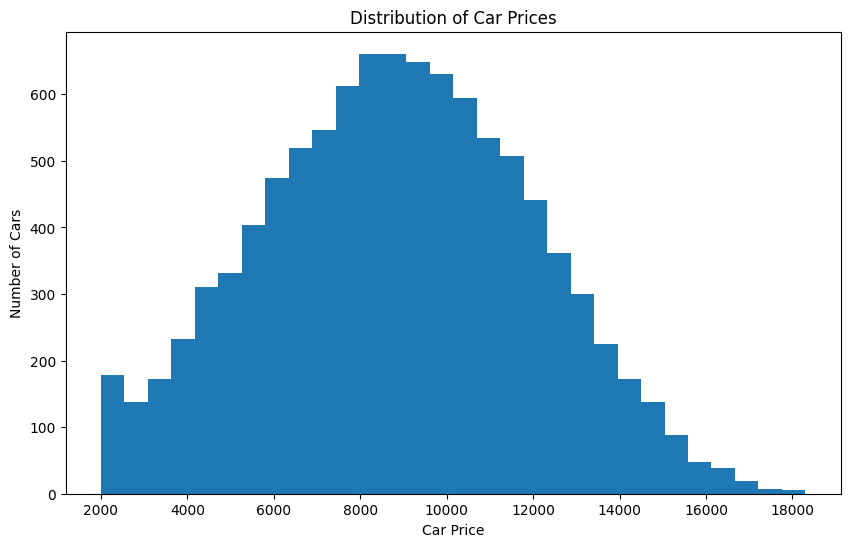

In [12]:
# Distribution of car prices

plt.figure(figsize=(10, 6))
plt.hist(df['Price'], bins=30)
plt.xlabel('Car Price')
plt.ylabel('Number of Cars')
plt.title('Distribution of Car Prices')
plt.show()

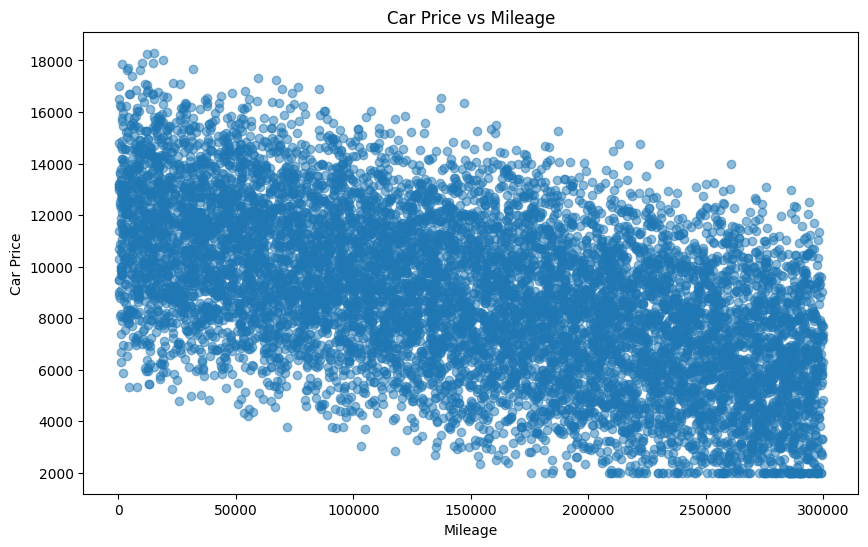

In [13]:
# Relationship between mileage and price

plt.figure(figsize=(10, 6))
plt.scatter(df['Mileage'], df['Price'], alpha=0.5)
plt.xlabel('Mileage')
plt.ylabel('Car Price')
plt.title('Car Price vs Mileage')
plt.show()

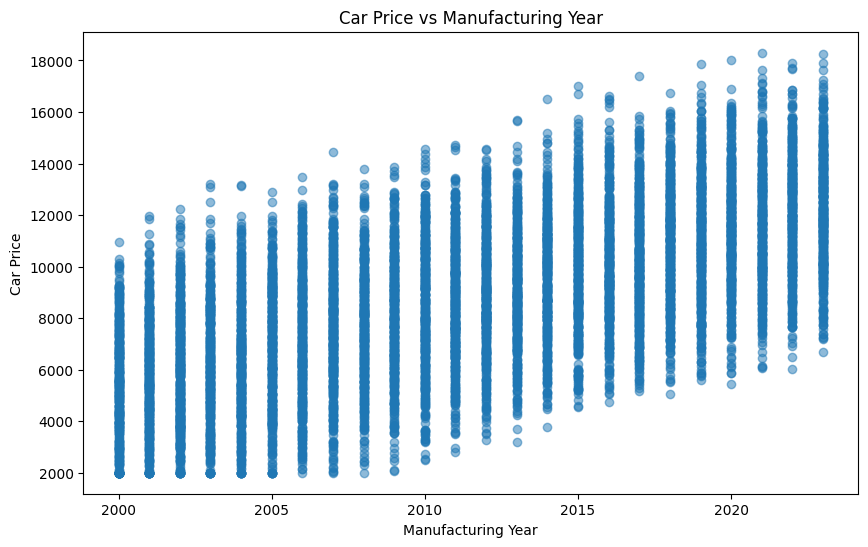

In [14]:
# Relationship between manufacturing year and price

plt.figure(figsize=(10, 6))
plt.scatter(df['Year'], df['Price'], alpha=0.5)
plt.xlabel('Manufacturing Year')
plt.ylabel('Car Price')
plt.title('Car Price vs Manufacturing Year')
plt.show()

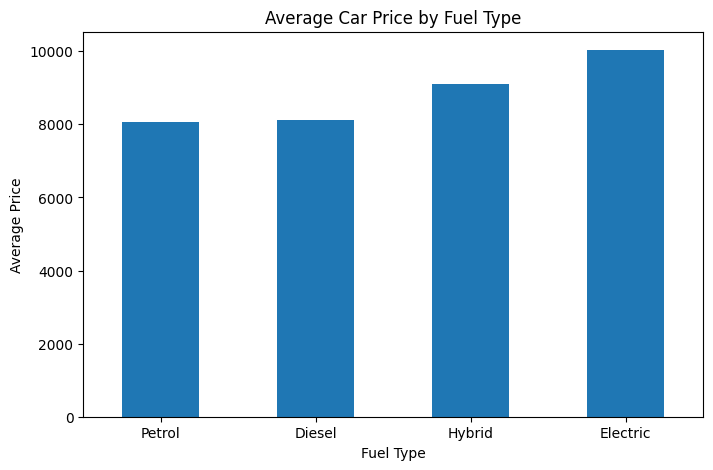

In [15]:
# Average car price by fuel type

fuel_price = df.groupby('Fuel_Type')['Price'].mean().sort_values()

plt.figure(figsize=(8, 5))
fuel_price.plot(kind='bar')
plt.xlabel('Fuel Type')
plt.ylabel('Average Price')
plt.title('Average Car Price by Fuel Type')
plt.xticks(rotation=0)
plt.show()

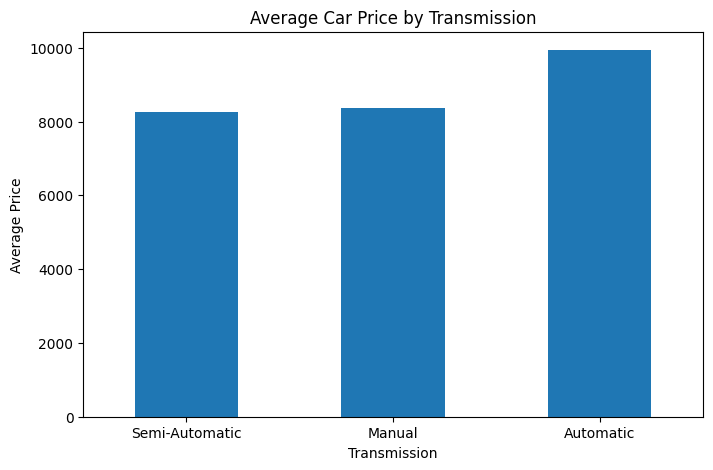

In [16]:
# Average car price by transmission type

transmission_price = df.groupby('Transmission')['Price'].mean().sort_values()

plt.figure(figsize=(8, 5))
transmission_price.plot(kind='bar')
plt.xlabel('Transmission')
plt.ylabel('Average Price')
plt.title('Average Car Price by Transmission')
plt.xticks(rotation=0)
plt.show()

## Exploratory Data Analysis

The exploratory data analysis was performed to understand the
relationship between different car features and their prices.

The visualizations help identify:
- The distribution of car prices.
- The relationship between mileage and price.
- The relationship between manufacturing year and price.
- Differences in average price based on fuel type.
- Differences in average price based on transmission type.

In [17]:
# Separate input features and target variable

X = df.drop('Price', axis=1)
y = df['Price']

print("Features:")
print(X.columns.tolist())

print("\nTarget variable: Price")

Features:
['Brand', 'Model', 'Year', 'Engine_Size', 'Fuel_Type', 'Transmission', 'Mileage', 'Doors', 'Owner_Count']

Target variable: Price


In [20]:
# Identify numerical and categorical features

categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(exclude=['object']).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['Brand', 'Model', 'Fuel_Type', 'Transmission']

Numerical features:
['Year', 'Engine_Size', 'Mileage', 'Doors', 'Owner_Count']


In [21]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 8000
Testing samples: 2000


In [22]:
# Preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [23]:
# Train Linear Regression model

linear_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [24]:
# Train Random Forest Regression model

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

print("Random Forest Regression model trained successfully!")

Random Forest Regression model trained successfully!


In [25]:
# Make predictions using both models

linear_predictions = linear_model.predict(X_test)
rf_predictions = rf_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [26]:
# Evaluate model performance

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Linear Regression")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)

print("\nRandom Forest Regression")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Linear Regression
MAE : 20.003593238655828
RMSE: 64.9147498869749
R²  : 0.9995413570910819

Random Forest Regression
MAE : 260.83626999999996
RMSE: 334.9177557002614
R²  : 0.987791445348444


## Machine Learning Models

Two regression algorithms were trained for car price prediction:

1. Linear Regression
2. Random Forest Regression

The models were evaluated using:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

These metrics help determine which model performs better on unseen data.

In [27]:
# Compare model performance

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regression'],
    'MAE': [linear_mae, rf_mae],
    'RMSE': [linear_rmse, rf_rmse],
    'R2 Score': [linear_r2, rf_r2]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,20.003593,64.914750,0.999541
1,Random Forest Regression,260.836270,334.917756,0.987791


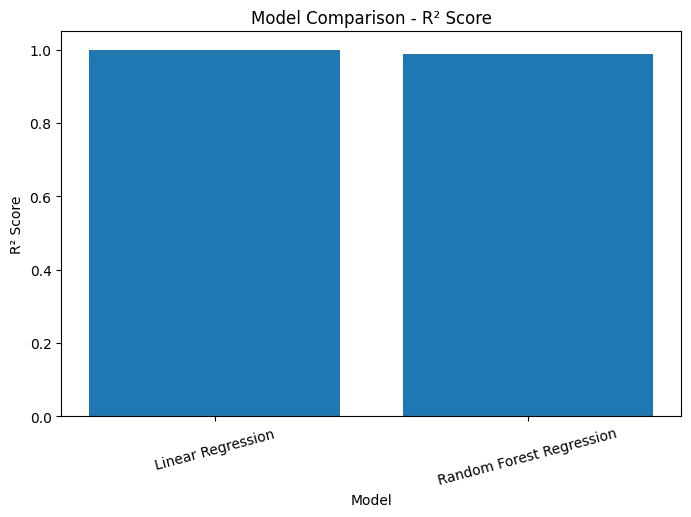

In [28]:
# Compare R² scores

plt.figure(figsize=(8, 5))

plt.bar(results['Model'], results['R2 Score'])

plt.xlabel('Model')
plt.ylabel('R² Score')
plt.title('Model Comparison - R² Score')
plt.xticks(rotation=15)

plt.show()

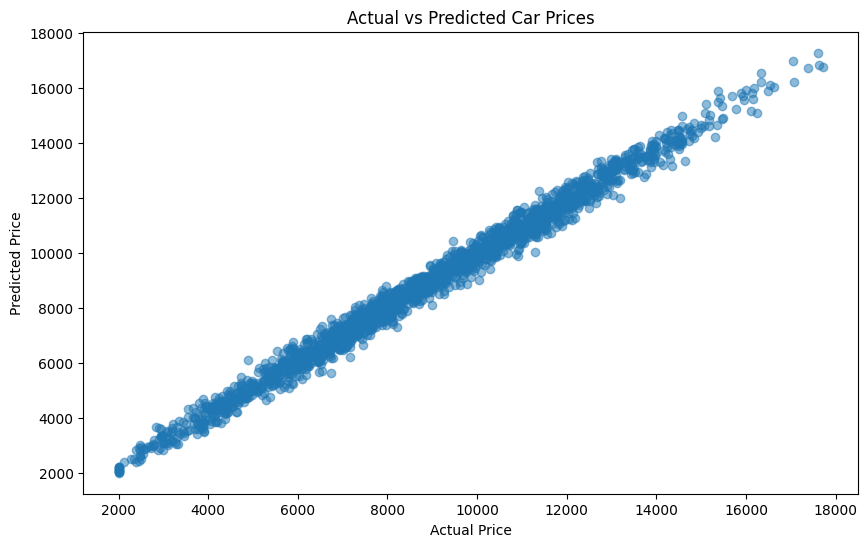

In [29]:
# Actual vs Predicted Car Prices

plt.figure(figsize=(10, 6))

plt.scatter(y_test, rf_predictions, alpha=0.5)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Car Prices')

plt.show()

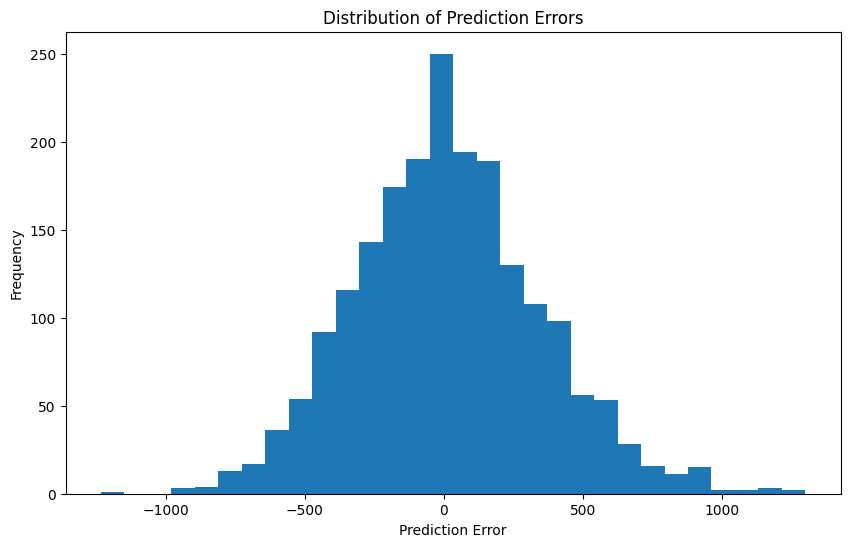

In [30]:
# Prediction errors

errors = y_test - rf_predictions

plt.figure(figsize=(10, 6))

plt.hist(errors, bins=30)

plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Errors')

plt.show()

In [31]:
# Select the model with the highest R² score

if rf_r2 > linear_r2:
    best_model = rf_model
    best_model_name = "Random Forest Regression"
else:
    best_model = linear_model
    best_model_name = "Linear Regression"

print("Best Model:", best_model_name)

Best Model: Linear Regression


## Model Comparison

The performance of Linear Regression and Random Forest Regression
was compared using MAE, RMSE, and R² Score.

The model with the higher R² Score and lower prediction errors
is considered the better-performing model for this dataset.

The selected model is then used for final car price prediction.

In [32]:
# Create sample car details for prediction

new_car = pd.DataFrame({
    'Brand': ['Toyota'],
    'Model': ['Corolla'],
    'Year': [2022],
    'Engine_Size': [1.8],
    'Fuel_Type': ['Petrol'],
    'Transmission': ['Automatic'],
    'Mileage': [30000],
    'Doors': [4],
    'Owner_Count': [1]
})

new_car

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count
0,Toyota,Corolla,2022,1.8,Petrol,Automatic,30000,4,1


In [33]:
# Predict the price of the new car

predicted_price = best_model.predict(new_car)

print("Predicted Car Price:", predicted_price[0])

Predicted Car Price: 13382.520324129371


In [34]:
# Display the prediction in a user-friendly format

print("====================================")
print("       CAR PRICE PREDICTION")
print("====================================")
print("Brand       :", new_car['Brand'].iloc[0])
print("Model       :", new_car['Model'].iloc[0])
print("Year        :", new_car['Year'].iloc[0])
print("Engine Size :", new_car['Engine_Size'].iloc[0])
print("Fuel Type   :", new_car['Fuel_Type'].iloc[0])
print("Transmission:", new_car['Transmission'].iloc[0])
print("Mileage     :", new_car['Mileage'].iloc[0])
print("Owner Count :", new_car['Owner_Count'].iloc[0])
print("------------------------------------")
print(f"Predicted Price: {predicted_price[0]:,.2f}")
print("====================================")

       CAR PRICE PREDICTION
Brand       : Toyota
Model       : Corolla
Year        : 2022
Engine Size : 1.8
Fuel Type   : Petrol
Transmission: Automatic
Mileage     : 30000
Owner Count : 1
------------------------------------
Predicted Price: 13,382.52


## Conclusion

In this project, a machine learning system was developed to predict
car prices using various vehicle features.

The project included:
- Data collection
- Data cleaning
- Exploratory Data Analysis
- Feature engineering
- Categorical data encoding
- Numerical feature scaling
- Train-test splitting
- Regression model training
- Model evaluation
- Car price prediction

Linear Regression and Random Forest Regression were trained and
compared using MAE, RMSE, and R² Score.

The better-performing model was selected for the final car price
prediction.

This project demonstrates how machine learning can be applied to
a real-world problem such as automobile price prediction.

## Future Scope

The project can be further improved by:

- Using a larger and more diverse car dataset.
- Applying advanced regression algorithms.
- Performing hyperparameter tuning.
- Adding more vehicle features.
- Developing a web-based car price prediction application.
- Deploying the model for real-time predictions.

---

## ✅ Final Result

The project successfully demonstrates the use of machine learning
for car price prediction.

Among the tested regression models, the model with the best
evaluation performance was selected for predicting the price of
new vehicles.

The project demonstrates the complete machine learning workflow
from data preprocessing to model training, evaluation, and
prediction.

---

### 👩‍💻 Developed by

**Apeksha G Bharadwaj**

**CodeAlpha Data Science Internship — Task 3**